# Stage 3 Experiment: Weight Initialization

This notebook evaluates how different initialization strategies affect optimization behaviour and final QA performance in the repaired QANet under a fixed baseline setting.


## 1. Research Question and Hypotheses

### Research Question

How does weight initialization affect the training dynamics and final QA performance of the repaired QANet under a fixed baseline setting?

More specifically, this experiment examines two related questions:
1. How strongly does weight initialization affect optimization stability, as reflected by training and development loss?
2. Are the observed differences driven more by initialization family (`Kaiming` vs `Xavier`) or by sampling form (`normal` vs `uniform`)?

### Hypotheses

Based on the role of initialization in deep network optimization, we propose the following hypotheses.

- `H1`: Weight initialization will significantly affect optimization stability in the repaired QANet, primarily reflected in the training loss and development loss curves.
- `H2`: Initialization family will have a stronger effect on training behaviour than sampling form. In particular, the difference between Kaiming-based and Xavier-based initialization is expected to be larger than the difference between normal and uniform sampling within the same family.
- `H3`: Initialization strategies that produce more stable optimization behaviour are expected to achieve better convergence quality and stronger final evaluation performance.


## 2. Experimental Setup

Controlled setting:
- same training and evaluation data
- same optimizer, scheduler, loss, and model structure
- only `init_name` is changed

Initialization settings compared:
- `kaiming`
- `xavier`
- `kaiming_uniform`
- `xavier_normal`


## 3. Load Libraries and Configuration


In [21]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

from TrainTools.train import train
from EvaluateTools.evaluate import evaluate

INIT_SETTINGS = [
    "kaiming",
    "xavier",
    "kaiming_uniform",
    "xavier_normal",
]

RESULTS_DIR = Path("experiments/init_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_RESULTS_PATH = RESULTS_DIR / "init_train_results.json"
EVAL_RESULTS_PATH = RESULTS_DIR / "init_eval_results.json"

train_results = {}
eval_results = {}


## 4. Run Training

This step trains all initialization settings under the same baseline and writes the results to `experiments/init_results/`.


In [22]:
for init_name in INIT_SETTINGS:
    print(f"===== Training init_name={init_name} =====")
    train_results[init_name] = train(
        train_npz       = "_data/train.npz",
        dev_npz         = "_data/dev.npz",
        word_emb_json   = "_data/word_emb.json",
        char_emb_json   = "_data/char_emb.json",
        train_eval_json = "_data/train_eval.json",
        dev_eval_json   = "_data/dev_eval.json",

        save_dir        = f"experiments/_model_init_{init_name}",
        log_dir         = f"experiments/_log_init_{init_name}",

        num_steps       = 1000,

        optimizer_name  = "sgd",
        scheduler_name  = "lambda",
        loss_name       = "qa_nll",
        init_name       = init_name,
    )

with TRAIN_RESULTS_PATH.open("w", encoding="utf-8") as f:
    json.dump(train_results, f, indent=2)


===== Training init_name=kaiming =====


100%|██████████| 200/200 [01:10<00:00,  2.83it/s]


STEP      200  loss 1821.687456



100%|██████████| 150/150 [00:16<00:00,  9.26it/s]


VALID(train) loss 34.274103  F1 7.092930  EM 0.000000



...

STEP     1000  loss 19.469221



100%|██████████| 150/150 [00:14<00:00, 10.58it/s]


VALID(train) loss 6.534443  F1 6.732330  EM 0.083333



100%|██████████| 150/150 [00:14<00:00, 10.51it/s]


TEST        loss 6.587584  F1 6.055193  EM 0.000000

Learning rate: [0.001]
Training finished.  Best F1: 6.5199  Best EM: 0.4167


## 5. Unified Evaluation

This step evaluates all saved checkpoints under the same evaluation protocol.


In [23]:
for init_name in INIT_SETTINGS:
    print(f"===== Evaluating init_name={init_name} =====")
    eval_results[init_name] = evaluate(
        dev_npz       = "_data/dev.npz",
        word_emb_json = "_data/word_emb.json",
        char_emb_json = "_data/char_emb.json",
        dev_eval_json = "_data/dev_eval.json",

        save_dir      = f"experiments/_model_init_{init_name}",
        log_dir       = f"experiments/_log_init_{init_name}",
    )

    print(
        f"Init={init_name} | Eval F1: {eval_results[init_name]['f1']:.4f} | "
        f"Eval EM: {eval_results[init_name]['exact_match']:.4f} | "
        f"Eval Loss: {eval_results[init_name]['loss']:.6f}"
    )

with EVAL_RESULTS_PATH.open("w", encoding="utf-8") as f:
    json.dump(eval_results, f, indent=2)


===== Evaluating init_name=kaiming =====


100%|██████████| 1309/1309 [02:01<00:00, 10.79it/s]


TEST  loss 17.387996  F1 7.597898  EM 0.172002
Init=kaiming | Eval F1: 7.5979 | Eval EM: 0.1720 | Eval Loss: 17.387996
===== Evaluating init_name=xavier =====


100%|██████████| 1309/1309 [02:01<00:00, 10.77it/s]


TEST  loss 6.445737  F1 8.567583  EM 0.000000
Init=xavier | Eval F1: 8.5676 | Eval EM: 0.0000 | Eval Loss: 6.445737
===== Evaluating init_name=kaiming_uniform =====


100%|██████████| 1309/1309 [02:01<00:00, 10.80it/s]


TEST  loss 23.760960  F1 7.952278  EM 0.047778
Init=kaiming_uniform | Eval F1: 7.9523 | Eval EM: 0.0478 | Eval Loss: 23.760960
===== Evaluating init_name=xavier_normal =====


100%|██████████| 1309/1309 [02:00<00:00, 10.82it/s]


TEST  loss 6.832353  F1 7.364475  EM 0.000000
Init=xavier_normal | Eval F1: 7.3645 | Eval EM: 0.0000 | Eval Loss: 6.832353


## 6. Summary Table

This table combines checkpoint-based training metrics with final evaluation results.


In [24]:
with TRAIN_RESULTS_PATH.open("r", encoding="utf-8") as f:
    train_results = json.load(f)
with EVAL_RESULTS_PATH.open("r", encoding="utf-8") as f:
    eval_results = json.load(f)

available_settings = [
    init_name for init_name in INIT_SETTINGS
    if init_name in train_results and init_name in eval_results
]

print("Available settings:", available_settings)

summary_rows = []
for init_name in available_settings:
    history = train_results[init_name]["history"]
    last_entry = history[-1]
    best_entry = max(history, key=lambda row: row["dev_f1"])
    summary_rows.append({
        "init_name": init_name,
        "last_step": last_entry["step"],
        "final_train_loss": last_entry["train_loss"],
        "final_dev_loss": last_entry["dev_loss"],
        "best_dev_f1": train_results[init_name]["best_f1"],
        "best_dev_em": train_results[init_name]["best_em"],
        "best_dev_step": best_entry["step"],
        "eval_f1": eval_results[init_name]["f1"],
        "eval_em": eval_results[init_name]["exact_match"],
        "eval_loss": eval_results[init_name]["loss"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values("init_name").reset_index(drop=True)
print(summary_df.to_string(index=False))
summary_df


Available settings: ['kaiming', 'xavier', 'kaiming_uniform', 'xavier_normal']
      init_name  last_step  final_train_loss  final_dev_loss  best_dev_f1  best_dev_em  best_dev_step  eval_f1  eval_em  eval_loss
        kaiming       1000        209.813018       16.832417     6.216593     0.166667            400 7.597898 0.172002  17.387996
kaiming_uniform       1000        412.054348       22.713580     7.103445     0.083333            400 7.952278 0.047778  23.760960
         xavier       1000         19.288335        6.284677     6.465764     0.000000           1000 8.567583 0.000000   6.445737
  xavier_normal       1000         19.469221        6.587584     6.519894     0.416667            400 7.364475 0.000000   6.832353


,init_name,last_step,final_train_loss,final_dev_loss,best_dev_f1,best_dev_em,best_dev_step,eval_f1,eval_em,eval_loss
0,kaiming,1000,209.813018,16.832417,6.216593,0.166667,400,7.597898,0.172002,17.387996
1,kaiming_uniform,1000,412.054348,22.713580,7.103445,0.083333,400,7.952278,0.047778,23.760960
2,xavier,1000,19.288335,6.284677,6.465764,0.000000,1000,8.567583,0.000000,6.445737
3,xavier_normal,1000,19.469221,6.587584,6.519894,0.416667,400,7.364475,0.000000,6.832353


## 7. Optimization Stability

These figures focus on loss behaviour, which is the main evidence for optimization stability.


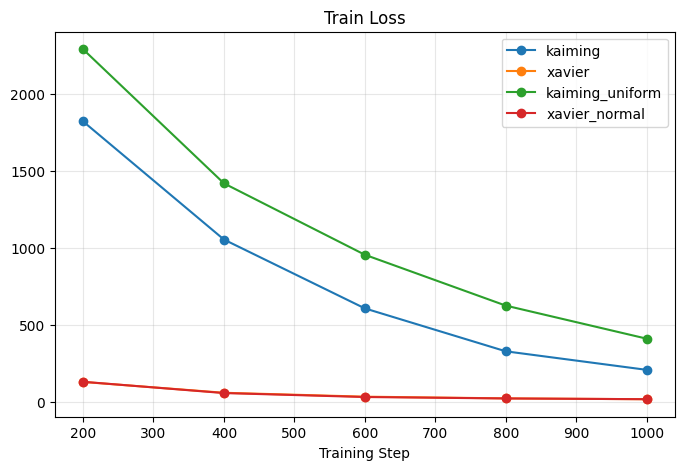

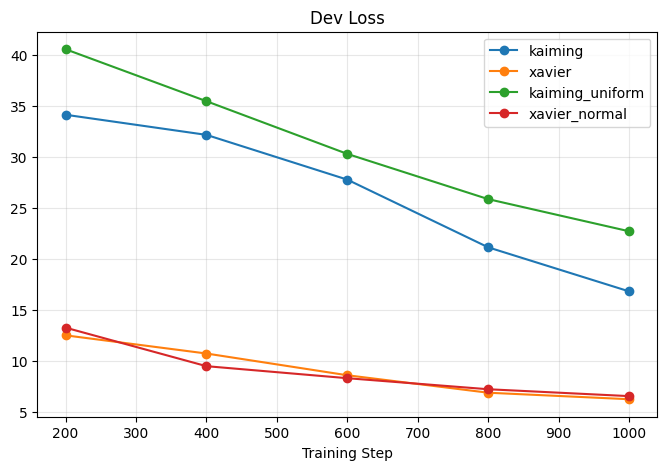

In [25]:
with TRAIN_RESULTS_PATH.open("r", encoding="utf-8") as f:
    train_results_disk = json.load(f)

available_settings_disk = [
    init_name for init_name in INIT_SETTINGS if init_name in train_results_disk
]

for metric_key, metric_title in [("train_loss", "Train Loss"), ("dev_loss", "Dev Loss")]:
    fig, ax = plt.subplots(figsize=(8, 5))
    for init_name in available_settings_disk:
        history_df = pd.DataFrame(train_results_disk[init_name]["history"])
        ax.plot(
            history_df["step"].tolist(),
            history_df[metric_key].tolist(),
            marker="o",
            label=init_name,
        )
    ax.set_title(metric_title)
    ax.set_xlabel("Training Step")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


In [ ]:
train_results = {}
eval_results = {}
available_settings = []

for init_name in INIT_SETTINGS:
    train_path = RESULTS_DIR / f"train_{init_name}.json"
    eval_path = RESULTS_DIR / f"eval_{init_name}.json"
    if train_path.exists() and eval_path.exists():
        with train_path.open("r", encoding="utf-8") as f:
            train_results[init_name] = json.load(f)
        with eval_path.open("r", encoding="utf-8") as f:
            eval_results[init_name] = json.load(f)
        available_settings.append(init_name)

if not available_settings:
    print("No summary rows available.")
else:
    for init_name in available_settings:
        print(
            f"Init={init_name} | Best Dev F1={train_results[init_name]['best_f1']:.4f} | "
            f"Best Dev EM={train_results[init_name]['best_em']:.4f} | Eval F1={eval_results[init_name]['f1']:.4f} | "
            f"Eval EM={eval_results[init_name]['exact_match']:.4f} | Eval Loss={eval_results[init_name]['loss']:.6f}"
        )


Init=kaiming | Best Dev F1=6.2166 | Best Dev EM=0.1667 | Eval F1=7.5979 | Eval EM=0.1720 | Eval Loss=17.387996
Init=xavier | Best Dev F1=6.4658 | Best Dev EM=0.0000 | Eval F1=8.5676 | Eval EM=0.0000 | Eval Loss=6.445737
Init=kaiming_uniform | Best Dev F1=7.1034 | Best Dev EM=0.0833 | Eval F1=7.9523 | Eval EM=0.0478 | Eval Loss=23.760960
Init=xavier_normal | Best Dev F1=6.5199 | Best Dev EM=0.4167 | Eval F1=7.3645 | Eval EM=0.0000 | Eval Loss=6.832353


## 8. Convergence Quality

These figures focus on development F1 and EM during training.


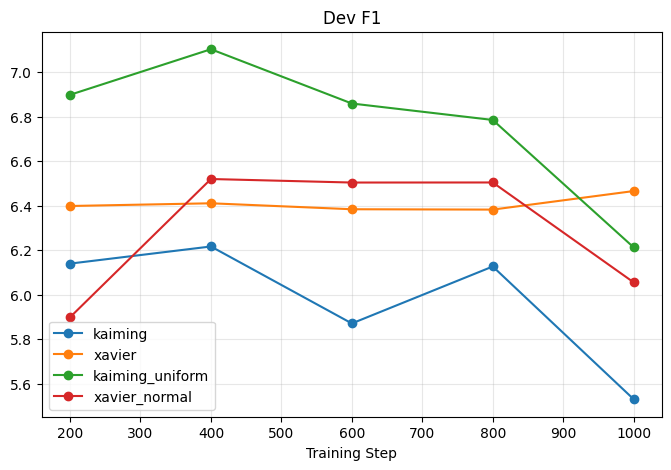

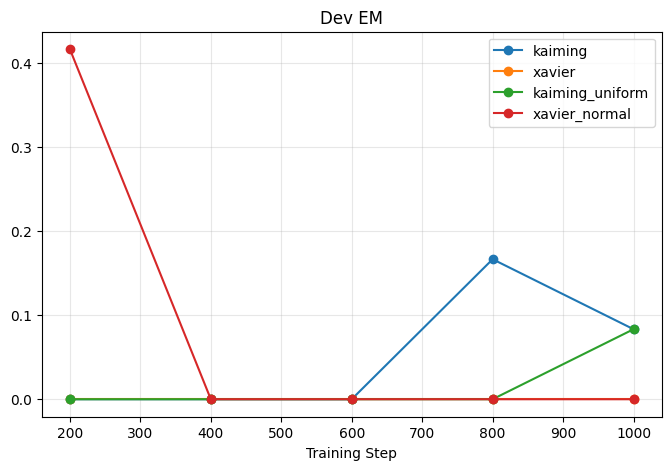

In [26]:
with TRAIN_RESULTS_PATH.open("r", encoding="utf-8") as f:
    train_results_disk = json.load(f)

available_settings_disk = [
    init_name for init_name in INIT_SETTINGS if init_name in train_results_disk
]

for metric_key, metric_title in [("dev_f1", "Dev F1"), ("dev_em", "Dev EM")]:
    fig, ax = plt.subplots(figsize=(8, 5))
    for init_name in available_settings_disk:
        history_df = pd.DataFrame(train_results_disk[init_name]["history"])
        ax.plot(
            history_df["step"].tolist(),
            history_df[metric_key].tolist(),
            marker="o",
            label=init_name,
        )
    ax.set_title(metric_title)
    ax.set_xlabel("Training Step")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


## 9. Final Outcome Comparison

These bar charts compare the final or best metrics across initialization settings.


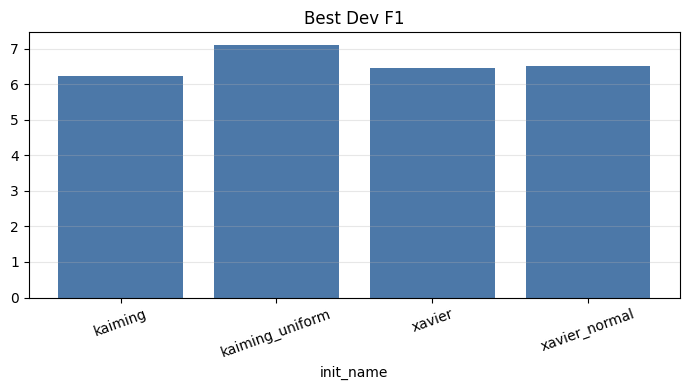

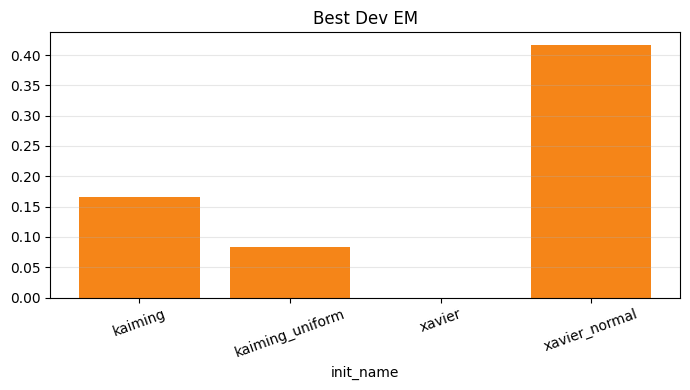

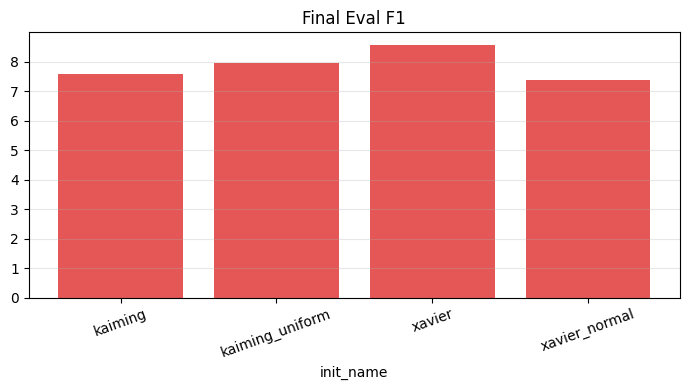

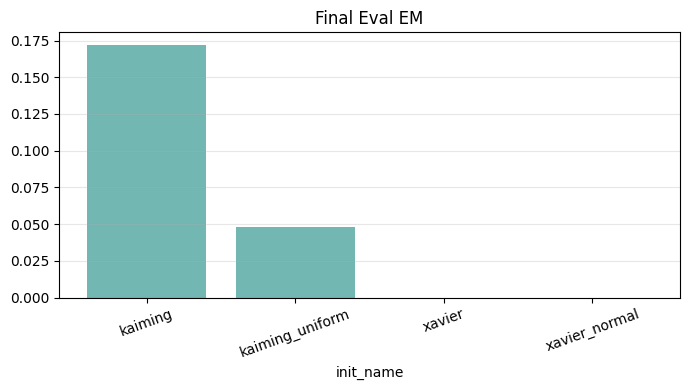

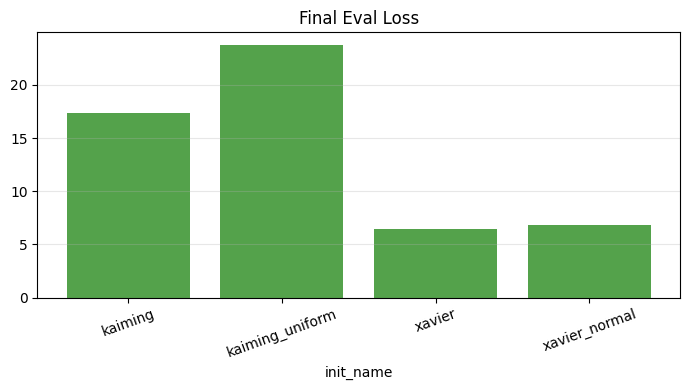

In [28]:
with TRAIN_RESULTS_PATH.open("r", encoding="utf-8") as f:
    train_results = json.load(f)
with EVAL_RESULTS_PATH.open("r", encoding="utf-8") as f:
    eval_results = json.load(f)

available_settings = [
    init_name for init_name in INIT_SETTINGS
    if init_name in train_results and init_name in eval_results
]

plot_rows = []
for init_name in available_settings:
    history = train_results[init_name]["history"]
    best_entry = max(history, key=lambda row: row["dev_f1"])
    plot_rows.append({
        "init_name": init_name,
        "best_dev_f1": train_results[init_name]["best_f1"],
        "best_dev_em": train_results[init_name]["best_em"],
        "best_dev_step": best_entry["step"],
        "eval_f1": eval_results[init_name]["f1"],
        "eval_em": eval_results[init_name]["exact_match"],
        "eval_loss": eval_results[init_name]["loss"],
    })

plot_df = pd.DataFrame(plot_rows)
plot_df = plot_df.sort_values("init_name").reset_index(drop=True)
x_labels = plot_df["init_name"].tolist()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x_labels, plot_df["best_dev_f1"], color="#4C78A8")
ax.set_title("Best Dev F1")
ax.set_xlabel("init_name")
ax.tick_params(axis="x", rotation=20)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x_labels, plot_df["best_dev_em"], color="#F58518")
ax.set_title("Best Dev EM")
ax.set_xlabel("init_name")
ax.tick_params(axis="x", rotation=20)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x_labels, plot_df["eval_f1"], color="#E45756")
ax.set_title("Final Eval F1")
ax.set_xlabel("init_name")
ax.tick_params(axis="x", rotation=20)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x_labels, plot_df["eval_em"], color="#72B7B2")
ax.set_title("Final Eval EM")
ax.set_xlabel("init_name")
ax.tick_params(axis="x", rotation=20)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x_labels, plot_df["eval_loss"], color="#54A24B")
ax.set_title("Final Eval Loss")
ax.set_xlabel("init_name")
ax.tick_params(axis="x", rotation=20)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
train_results = {}
eval_results = {}
available_settings = []

for init_name in INIT_SETTINGS:
    train_path = RESULTS_DIR / f"train_{init_name}.json"
    eval_path = RESULTS_DIR / f"eval_{init_name}.json"
    if train_path.exists() and eval_path.exists():
        with train_path.open("r", encoding="utf-8") as f:
            train_results[init_name] = json.load(f)
        with eval_path.open("r", encoding="utf-8") as f:
            eval_results[init_name] = json.load(f)
        available_settings.append(init_name)

if not available_settings:
    print("No summary rows available.")
else:
    for init_name in available_settings:
        print(
            f"Init={init_name} | Best Dev F1={train_results[init_name]['best_f1']:.4f} | "
            f"Best Dev EM={train_results[init_name]['best_em']:.4f} | Eval F1={eval_results[init_name]['f1']:.4f} | "
            f"Eval EM={eval_results[init_name]['exact_match']:.4f} | Eval Loss={eval_results[init_name]['loss']:.6f}"
        )


Init=kaiming | Best Dev F1=6.2166 | Best Dev EM=0.1667 | Eval F1=7.5979 | Eval EM=0.1720 | Eval Loss=17.387996
Init=xavier | Best Dev F1=6.4658 | Best Dev EM=0.0000 | Eval F1=8.5676 | Eval EM=0.0000 | Eval Loss=6.445737
Init=kaiming_uniform | Best Dev F1=7.1034 | Best Dev EM=0.0833 | Eval F1=7.9523 | Eval EM=0.0478 | Eval Loss=23.760960
Init=xavier_normal | Best Dev F1=6.5199 | Best Dev EM=0.4167 | Eval F1=7.3645 | Eval EM=0.0000 | Eval Loss=6.832353
